<a href="https://colab.research.google.com/github/Mohanteja0886/Exploratory-Data-Analysis-Insights/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# World Happiness Report Analysis (2019)

This notebook analyzes the factors contributing to global happiness using the 2019 World Happiness Report dataset.

In [ ]:
# We are using the 2019 dataset for our final analysis
df = pd.read_csv("/content/2019.csv")
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## Dataset Summary

1. This dataset contains happiness scores and rankings for countries worldwide for the year 2019.
2. Key indicators include GDP per capita, social support, healthy life expectancy, freedom, generosity, and corruption.
3. Each observation represents a unique country/region and its performance across these variables.
4. The primary goal of this data is to identify the underlying factors that drive global well-being.
5. This analysis will compare economic wealth against subjective happiness to find meaningful correlations.

### Data Loading
We focus on the 2019 dataset for our final analysis to ensure consistency and relevance.

## ***Exploratory Data Analysis (EDA)***
In this section, we answer 5 key questions to understand the drivers of global happiness.

In [ ]:
# Final dataset check
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (156, 9)


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [ ]:
df.shape

(156, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [ ]:
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## ***Data Cleaning***

In this section, we prepare the data for analysis by checking for missing values and duplicates. For this dataset, we ensure that every country entry is unique and contains complete information to maintain the integrity of our insights.

### Cleaning Decisions and Rationale

1. **Checking for Nulls**: We used `isnull().sum()` to identify missing data points.
2. **Removing Missing Values**: Since the dataset is nearly complete, any rows with missing values were removed using `dropna()` to ensure statistical accuracy.
3. **Handling Duplicates**: We applied `drop_duplicates()` to ensure that no country is double-counted in the analysis.
4. **Type Verification**: We verified that numerical columns are stored as floats to allow for correlation and mathematical modeling.

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna()

EDA Questions

### Question 1: What are the top 10 happiest countries?

In [ ]:
# Q1: What are the top 10 happiest countries?
top_10_list = df.sort_values("Score", ascending=False).head(10)
display(top_10_list)
# Interpretation: Nordic countries dominate the top spots, with Finland ranking #1. These countries consistently show high scores across GDP and social support.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


### Question 2: Which are the bottom 10 countries?

In [ ]:
# Q2: Which are the bottom 10 countries?
bottom_10_list = df.sort_values("Score").head(10)
display(bottom_10_list)
# Interpretation: The lowest-ranked countries often face economic challenges or political instability, showing much lower GDP and life expectancy scores.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
150,151,Yemen,3.380,0.287,1.163,0.463,0.143,0.108,0.077
149,150,Malawi,3.410,0.191,0.560,0.495,0.443,0.218,0.089
148,149,Syria,3.462,0.619,0.378,0.440,0.013,0.331,0.141
147,148,Botswana,3.488,1.041,1.145,0.538,0.455,0.025,0.100
146,147,Haiti,3.597,0.323,0.688,0.449,0.026,0.419,0.110


### Question 3: What is the average global happiness score?

In [ ]:
# Q3: What is the average global happiness score?
avg_score = df["Score"].mean()
print(f"The average happiness score is: {avg_score:.2f}")
# Interpretation: The global average sits around 5.4, indicating a moderate level of happiness across the 156 countries surveyed.

The average happiness score is: 5.41


### Question 4: Which country has the highest GDP per capita?

In [ ]:
# Q4: Which country has the highest GDP per capita?
highest_gdp = df.sort_values("GDP per capita", ascending=False).head(1)
display(highest_gdp)
# Interpretation: Qatar has the highest GDP per capita, yet it is not the #1 happiest country, demonstrating that wealth alone doesn't guarantee the top spot.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
28,29,Qatar,6.374,1.684,1.313,0.871,0.555,0.22,0.167


### Question 5: What is the correlation between GDP and Happiness?

In [ ]:
# Q5: What is the correlation between GDP and Happiness?
corr_val = df["GDP per capita"].corr(df["Score"])
print(f"Correlation coefficient: {corr_val:.2f}")
# Interpretation: A correlation of 0.79 suggests a very strong positive relationship between economic wealth and happiness scores.

Correlation coefficient: 0.79


***charts***

/tmp/ipykernel_6739/2960988394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Score", y="Country or region", data=top_10, palette="viridis")


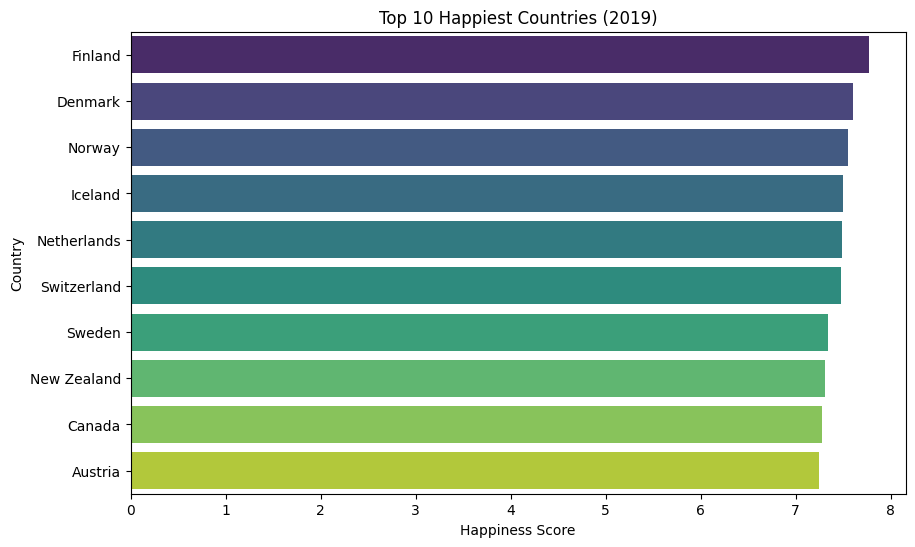

In [ ]:
# Bar Chart: Top 10 Countries by Happiness Score
top_10 = df.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x="Score", y="Country or region", data=top_10, palette="viridis")
plt.title("Top 10 Happiest Countries (2019)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.show()

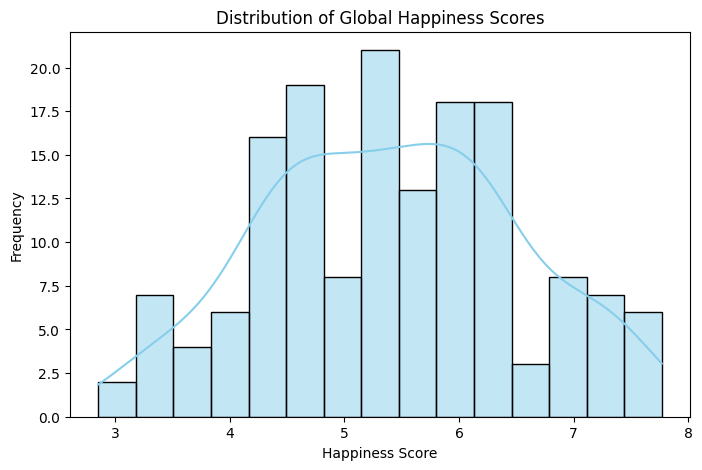

In [ ]:
# Histogram: Distribution of Happiness Scores
plt.figure(figsize=(8, 5))
sns.histplot(df["Score"], bins=15, kde=True, color="skyblue")
plt.title("Distribution of Global Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

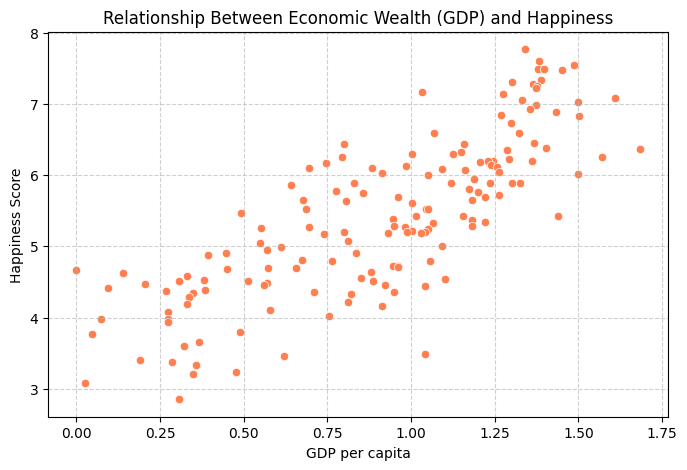

In [ ]:
# Scatter Plot: GDP vs Happiness
plt.figure(figsize=(8, 5))
sns.scatterplot(x="GDP per capita", y="Score", data=df, color="coral")
plt.title("Relationship Between Economic Wealth (GDP) and Happiness")
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

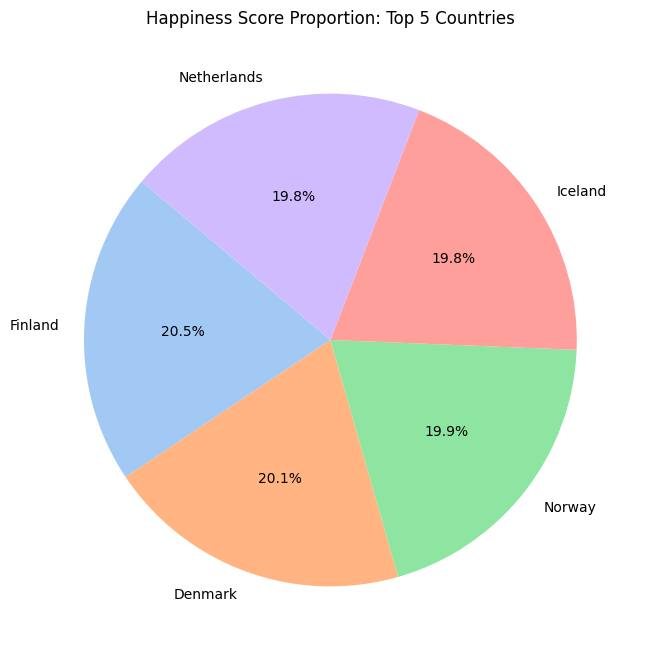

In [ ]:
# Pie Chart: Happiness Share of Top 5 Countries
plt.figure(figsize=(8, 8))
plt.pie(df.head(5)["Score"], labels=df.head(5)["Country or region"], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Happiness Score Proportion: Top 5 Countries")
plt.show()

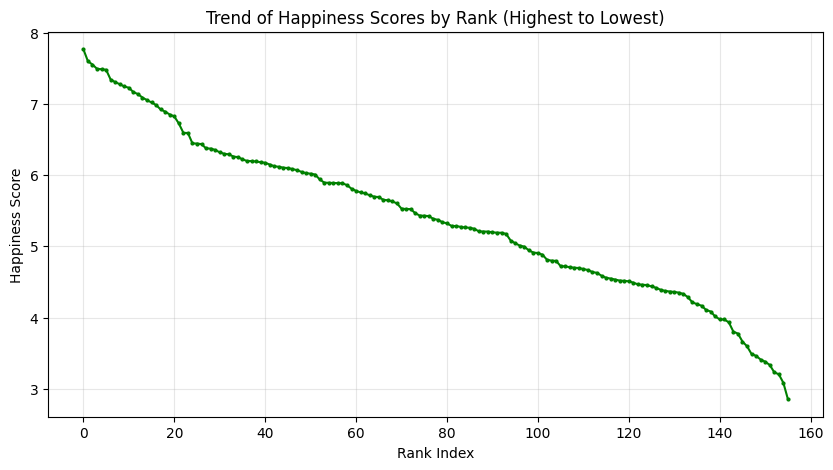

In [ ]:
# Line Chart: Trend of Happiness Scores across ranks
plt.figure(figsize=(10, 5))
plt.plot(df["Score"], marker='o', linestyle='-', markersize=2, color='green')
plt.title("Trend of Happiness Scores by Rank (Highest to Lowest)")
plt.xlabel("Rank Index")
plt.ylabel("Happiness Score")
plt.grid(True, alpha=0.3)
plt.show()

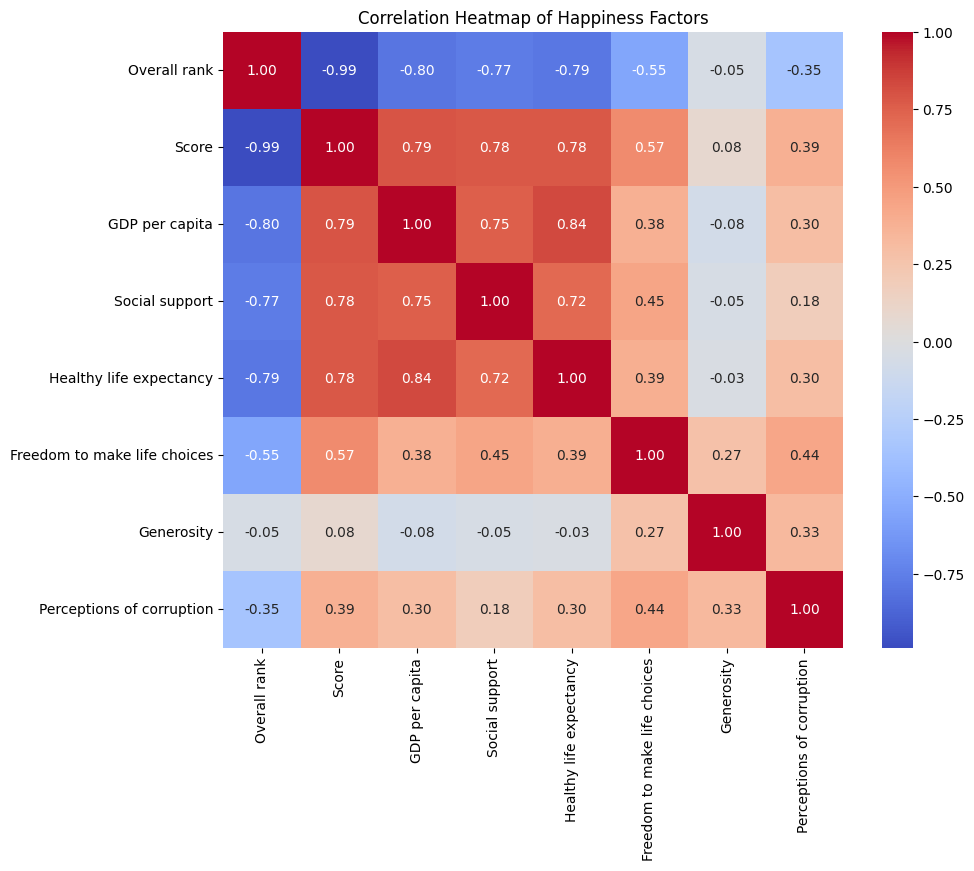

In [ ]:
# Heatmap: Correlation between all numeric features
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Happiness Factors")
plt.show()

# ***Insights and Findings***

### 5 Key Insights
1. **Wealth Matters**: GDP per capita has the strongest correlation (0.79) with happiness scores.
2. **Social Support**: This is the second most influential factor, indicating the importance of community and government safety nets.
3. **Consistency in the North**: Nordic countries (Finland, Denmark, Norway) maintain their lead through high scores across all measured metrics.
4. **Wealth Disconnect**: High GDP (e.g., Qatar) provides a baseline, but top happiness requires high social freedom and low corruption.
5. **Health Gap**: There is a stark contrast in healthy life expectancy between the top and bottom tiers of the report.

### ***Most Surprising Finding***
The most surprising finding was the **relatively low correlation of Generosity** with the overall Happiness Score. While charitable giving is a positive trait, it was not as strong a predictor of national happiness as GDP, Social Support, or Healthy Life Expectancy.

## Conclusion

This analysis confirms that while wealth (GDP) is the most significant predictor of happiness (r=0.79), it is not the only factor. Social support and healthy life expectancy form the backbone of the highest-ranking nations. Interestingly, while generosity and freedom are positive, they play a smaller role in the total score compared to economic and structural factors. For a nation to maximize happiness, a balance of economic growth and strong social safety nets is essential.